# from the version of the notebook data_cleaning_of_lapses.ipynb resulted a dataframe named data_vefore_model.parquet. this file is to queep removing data inconsistencies from the data sin the first version was getting to big  so in this file i will import the resulting datasetr and keep cleaning it 


##################################################################################################################################################################################################################################################

# atention this script  takes a data file and outputs another so be carful to change the name of the output file before running it otherwise it will save on top 

# importing libraries 

In [1]:
import pandas as pd 

import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

# loading the data file

In [2]:
data = pd.read_parquet("data_before_model3.parquet")

In [3]:
#because i have changed the code in the previous file for the extended dataset i also changed the name of the poliza features in the feature engenearing i used uppercase  so lets correct it so the file runs 
cols_to_change_name = [ col for col in data if col.endswith("_POLIZA")]
data.rename(columns={col: col.replace("_POLIZA", "_poliza") for col in cols_to_change_name}, inplace=True)

In [4]:
# first col to popup is the TRANSF_SEGURO_EXT this col has 2 distinct values the thing is 


In [5]:
data.TRANSF_SEGURO_EXT.value_counts()
#TRANSF_SEGURO_EXT
#N    27833
#S     1139
#Name: count, dtype: int64
data.groupby("is_lapse")["TRANSF_SEGURO_EXT"].value_counts()

#is_lapse  TRANSF_SEGURO_EXT
#0         N                    26302
#          S                     1091
#1         N                     1531
#          S                       48
#Name: count, dtype: int64


data.groupby("is_lapse")["TRANSF_SEGURO_EXT"].value_counts(normalize = True)*100

#
#is_lapse  TRANSF_SEGURO_EXT
#0         N                    96.017231
#          S                     3.982769
#1         N                    96.960101
#          S                     3.039899
#   Name: proportion, dtype: float64


# now lets see the trans seg int 

data.TRANSF_SEGURO_INT.value_counts()

#TRANSF_SEGURO_INT
#N    15253
#S    13719
#Name: count, dtype: int64


data.groupby("is_lapse")["TRANSF_SEGURO_INT"].value_counts()
#is_lapse  TRANSF_SEGURO_INT
#0         N                    14219
#          S                    13174
#1         N                     1034
#          S                      545
#Name: count, dtype: int64

data.groupby("is_lapse")["TRANSF_SEGURO_INT"].value_counts(normalize =True )*100
#is_lapse  TRANSF_SEGURO_INT
#0         N                    51.907422
#          S                    48.092578
#1         N                    65.484484
#          S                    34.515516
#Name: proportion, dtype: float64





#as can bee sen the coll TRANSF_SEGURO_EXT has a very low proportion of S values and the distribution of this variable is very unbalanced  between the 2 classes so i will exclude it from the model

is_lapse  TRANSF_SEGURO_INT
0         N                    50.808665
          S                    49.191335
1         N                    67.500000
          S                    32.500000
Name: proportion, dtype: float64

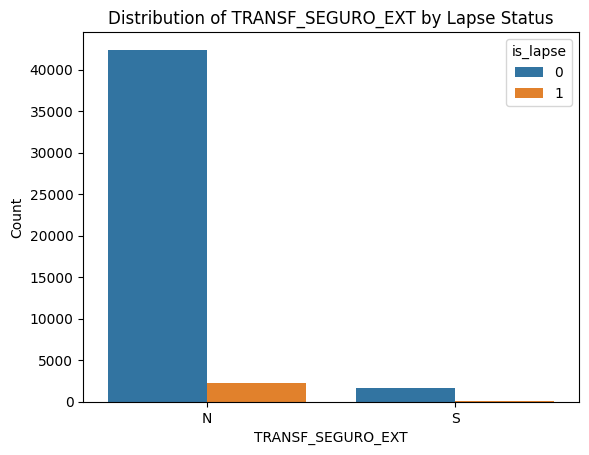

In [6]:
# Plot class distribution with lapse count as hue
sns.countplot(data=data, x="TRANSF_SEGURO_EXT", hue="is_lapse")
plt.title("Distribution of TRANSF_SEGURO_EXT by Lapse Status")
plt.xlabel("TRANSF_SEGURO_EXT")
plt.ylabel("Count")
plt.legend(title="is_lapse")
plt.show()

In [7]:
data= data.drop(columns=["TRANSF_SEGURO_EXT"])

In [8]:
# excluding the new_ant_pessoa since i have that info in ant_pessoa 
data= data.drop(columns=["new_ant_pessoa"])

In [9]:
# excluding thed codpost_tomador  since this is too detailed info i will have to convert it int o a cat var but this one has 13858 unique values thus it woulod explofde the dimentionality of the model i can in the future use a transformation of this variable like taking just the first 4 numbers of the first tree 
data= data.drop(columns=["codpost_tomador"])

In [10]:
# all tyhe capital insured cols i dont know if it makes that much sense to use them as numerical variables because they usually only have  2 , 3 or 4 distinct values and i have created a col with all the possible combinations of the coverages and im left with only 5 diferent combinations  so maybe it does not make sense  
# to include them as  numerical variables 
coverage_variables = ["Capital_Hosp_Cirurgia_e_Parto",
                      "Capital_Parto",
                      "Capital_Hosp_Cirurgia",
                      "Capital_Prot_n_Oculares",
                      "Capital_Prot_Oculares",
                      "Capital_Cob_Medica_Int",
                      "Capital_Consultas",
                      "Capital_Medicamentos",
                      "Capital_Estomat_Consult_e_Trat",
                      "Cap_Oncologia"

] 

In [11]:
# THE imc COLL HAS ALSO SOIMETHING WRONG ( I USEED BINS TO SUBSTITUTE THE COLS OF PESSO AND NEW_ESTATURA BUTSTILL THERE WHERE SOME MAD VALUES IN HOSE COLS WICH I ALSO SUBSTITUTED BUT STILL IM GETTING SOME TAIL VALUES OF 850000 WICH IS IMPOSSIBLE WELL )
# USSUSALLY imc SITS BETWENN  18 AND 40  SO IM GONNA SUBSTITUTE VALUES ABOVE THIS RANGE AND BELOW BY  26.8
mask = (data["IMC"] < 18) | (data["IMC"] > 40)
data.loc[mask, "IMC"] = 26.8
# solved


In [12]:
# now lets solve3 the N_hospitaisd_pp2 wich is the number of parcerias publico privadas in portugal there is also  a mad class inbalance 
data.N_hospitais_PP2.value_counts(),data.N_hospitais_PP2.value_counts(normalize = True)*100 ,data.groupby("is_lapse")["N_hospitais_PP2"].value_counts(normalize = True)*100

#(N_hospitais_PP2
# 0.0    26608
# 1.0     2364
## Name: count, dtype: int64,
# N_hospitais_PP2
# 0.0    91.840398
# 1.0     8.159602
# Name: proportion, dtype: float64,
# is_lapse  N_hospitais_PP2
#3 0         0.0                91.881138
#           1.0                 8.118862
# 1         0.0                91.133629
#           1.0                 8.866371
# Name: proportion, dtype: float64)
# as can bee seen this variable will not introduce much info to the model  so lets drop it 
data= data.drop(columns=["N_hospitais_PP2"])

In [13]:
# for the cols Prop_homens and Prop_mulheres  guess what the correlation is preciselly -1 so including both variables dont make sense 
#thus lets drop one of them 
data= data.drop(columns=["Prop_mulheres"])

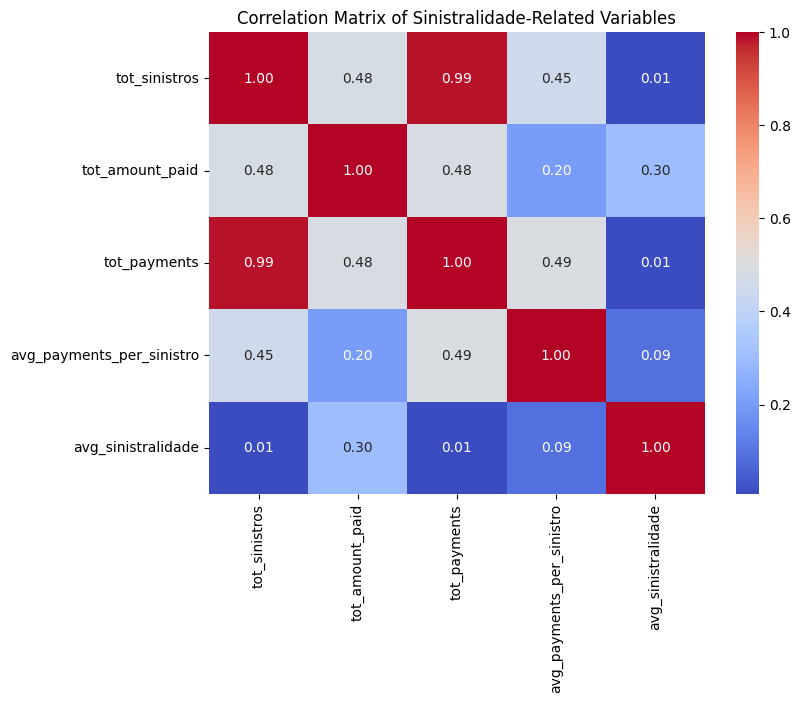

In [14]:

sinist_rel = data[["tot_sinistros", "tot_amount_paid", "tot_payments", "avg_payments_per_sinistro", "avg_sinistralidade"]]
cor_matrix = sinist_rel.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Sinistralidade-Related Variables")
plt.show()

In [15]:
# the relation betwenn the tot_payments and tot_sinistros is pretty high so loets drop the total paymens because i still have info about the average payment per sinister 
data= data.drop(columns=["tot_payments"])

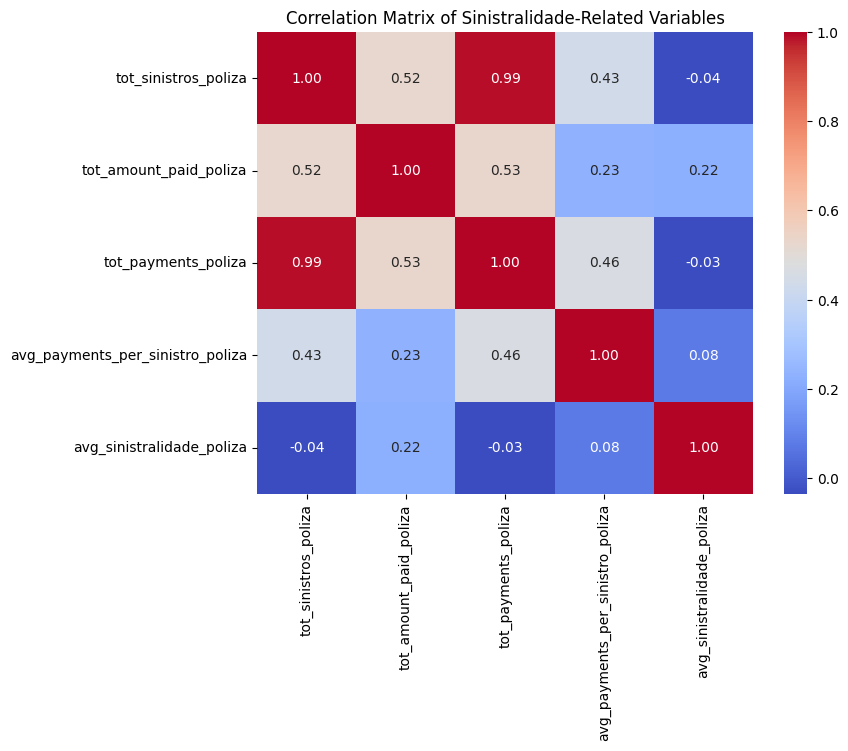

In [16]:
# lets asses the same thing about the poliza and sinisters
sins_rel_poliza = data[["tot_sinistros_poliza", "tot_amount_paid_poliza","tot_payments_poliza","avg_payments_per_sinistro_poliza","avg_sinistralidade_poliza"]]
cor_matrix = sins_rel_poliza.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Sinistralidade-Related Variables")
plt.show()

In [17]:
#we have the bsame correlation structure  so lets also drop the tot_payments_poliza
data= data.drop(columns=["tot_payments_poliza"])

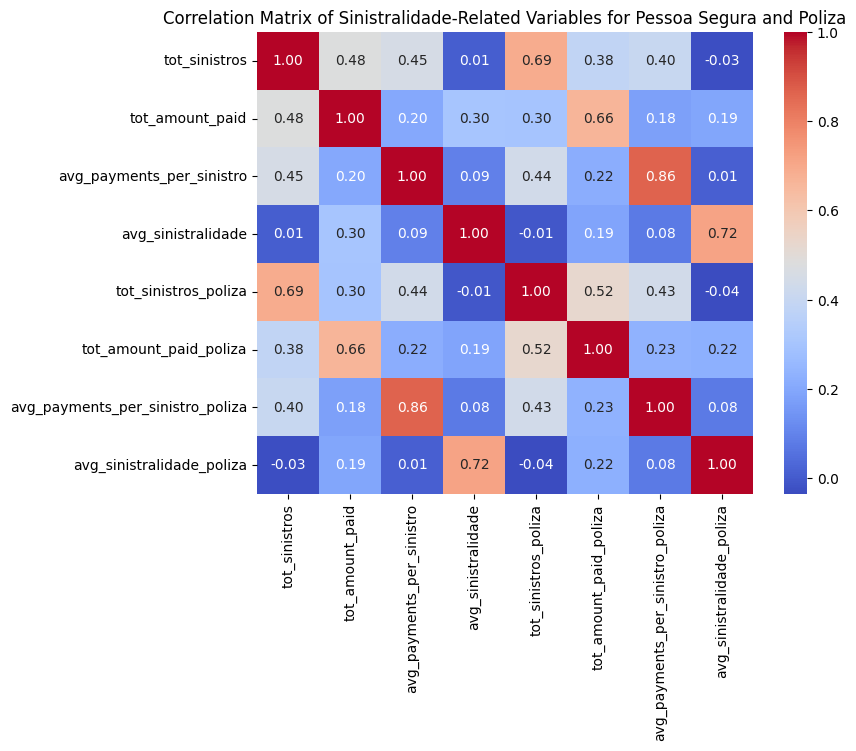

In [18]:
#now lets check the relationships between the sinistrealidade cols of the pessoa segura nad the poliza as a whoile the corr will be strong since a lot of policies have only 1 policyholder 
sins_rel_poliza_pessoa = data[["tot_sinistros", "tot_amount_paid","avg_payments_per_sinistro","avg_sinistralidade","tot_sinistros_poliza","tot_amount_paid_poliza","avg_payments_per_sinistro_poliza","avg_sinistralidade_poliza"]]
cor_matrix = sins_rel_poliza_pessoa.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Sinistralidade-Related Variables for Pessoa Segura and Poliza")
plt.show()

In [19]:
# as expected the correlation of the same variables but for pp and poliza are high 0.87 for the avg_payments_per_sinistro and 0.72 for the avg sinistralidade  so lets drop the avg payments per sinistro of the poliza since i have the same info for the pessoa segura and the correlation is very high
data= data.drop(columns=["avg_payments_per_sinistro_poliza"])

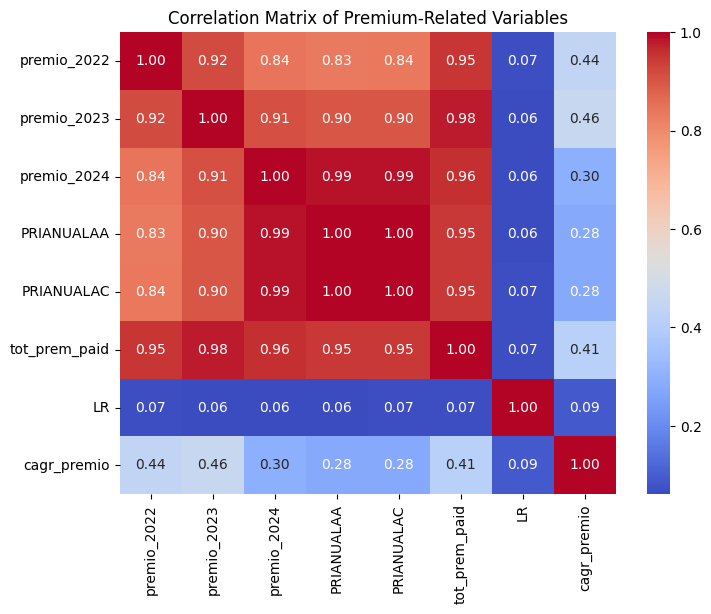

In [20]:
#lets check the correlation between the  premios the total premium paid  the LR and the cgar_premium 
prem_cols = ["premio_2022", "premio_2023","premio_2024","PRIANUALAA","PRIANUALAC","tot_prem_paid", "LR", "cagr_premio"]
prem_rel = data[prem_cols]
cor_matrix = prem_rel.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Premium-Related Variables")
plt.show()


In [21]:
#lets first include a columns with the nominal value of premium increase 
data["nom_prem_inc"]=data["PRIANUALAC"]- data["PRIANUALAA"]

In [22]:
# so lets drop the premios,and the Prianualaa since i have info about the proposed premium increase 
data= data.drop(columns=["premio_2022", "premio_2023","premio_2024","PRIANUALAA"])

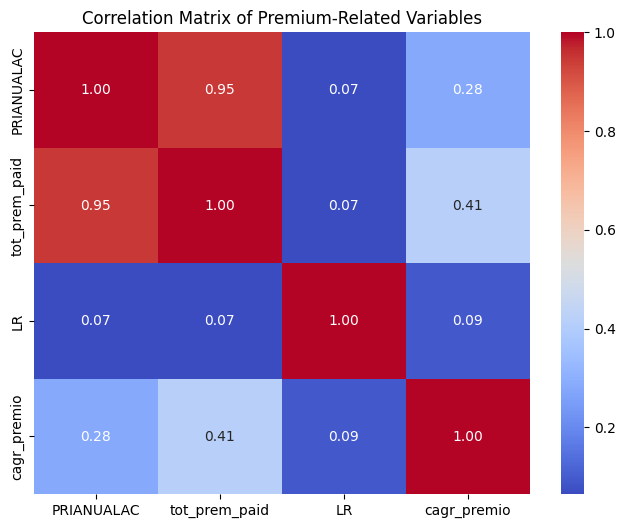

In [23]:
prem_cols = ["PRIANUALAC","tot_prem_paid", "LR", "cagr_premio"]
prem_rel = data[prem_cols]
cor_matrix = prem_rel.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Premium-Related Variables")
plt.show()

In [24]:
# im left with  a huge correlation on the  tot_premium_paid and the prianualac so lets drop the total premium paid 
data= data.drop(columns=["tot_prem_paid"])

In [25]:
# lets explore the more_than1p col this coll flags policy holders with more than 1 policy  of course this is a extreme small percentage boff al the cases 

data.more_then_1p.value_counts(),data.more_then_1p.value_counts(normalize=True)*100,data.groupby("is_lapse")["more_then_1p"].value_counts(normalize=True)*100



#more_then_1p
# 0    28950
# 1       22
# Name: count, dtype: int64,
# more_then_1p
# 0    99.924065
# 1     0.075935
# Name: proportion, dtype: float64,
# is_lapse  more_then_1p
# 0         0               99.923338
#           1                0.076662
# 1         0               99.936669
#           1                0.063331
# Name: proportion, dtype: float64)


# with this kinfd of values it does not make sense to include this variable 



data = data.drop(columns=["more_then_1p"])


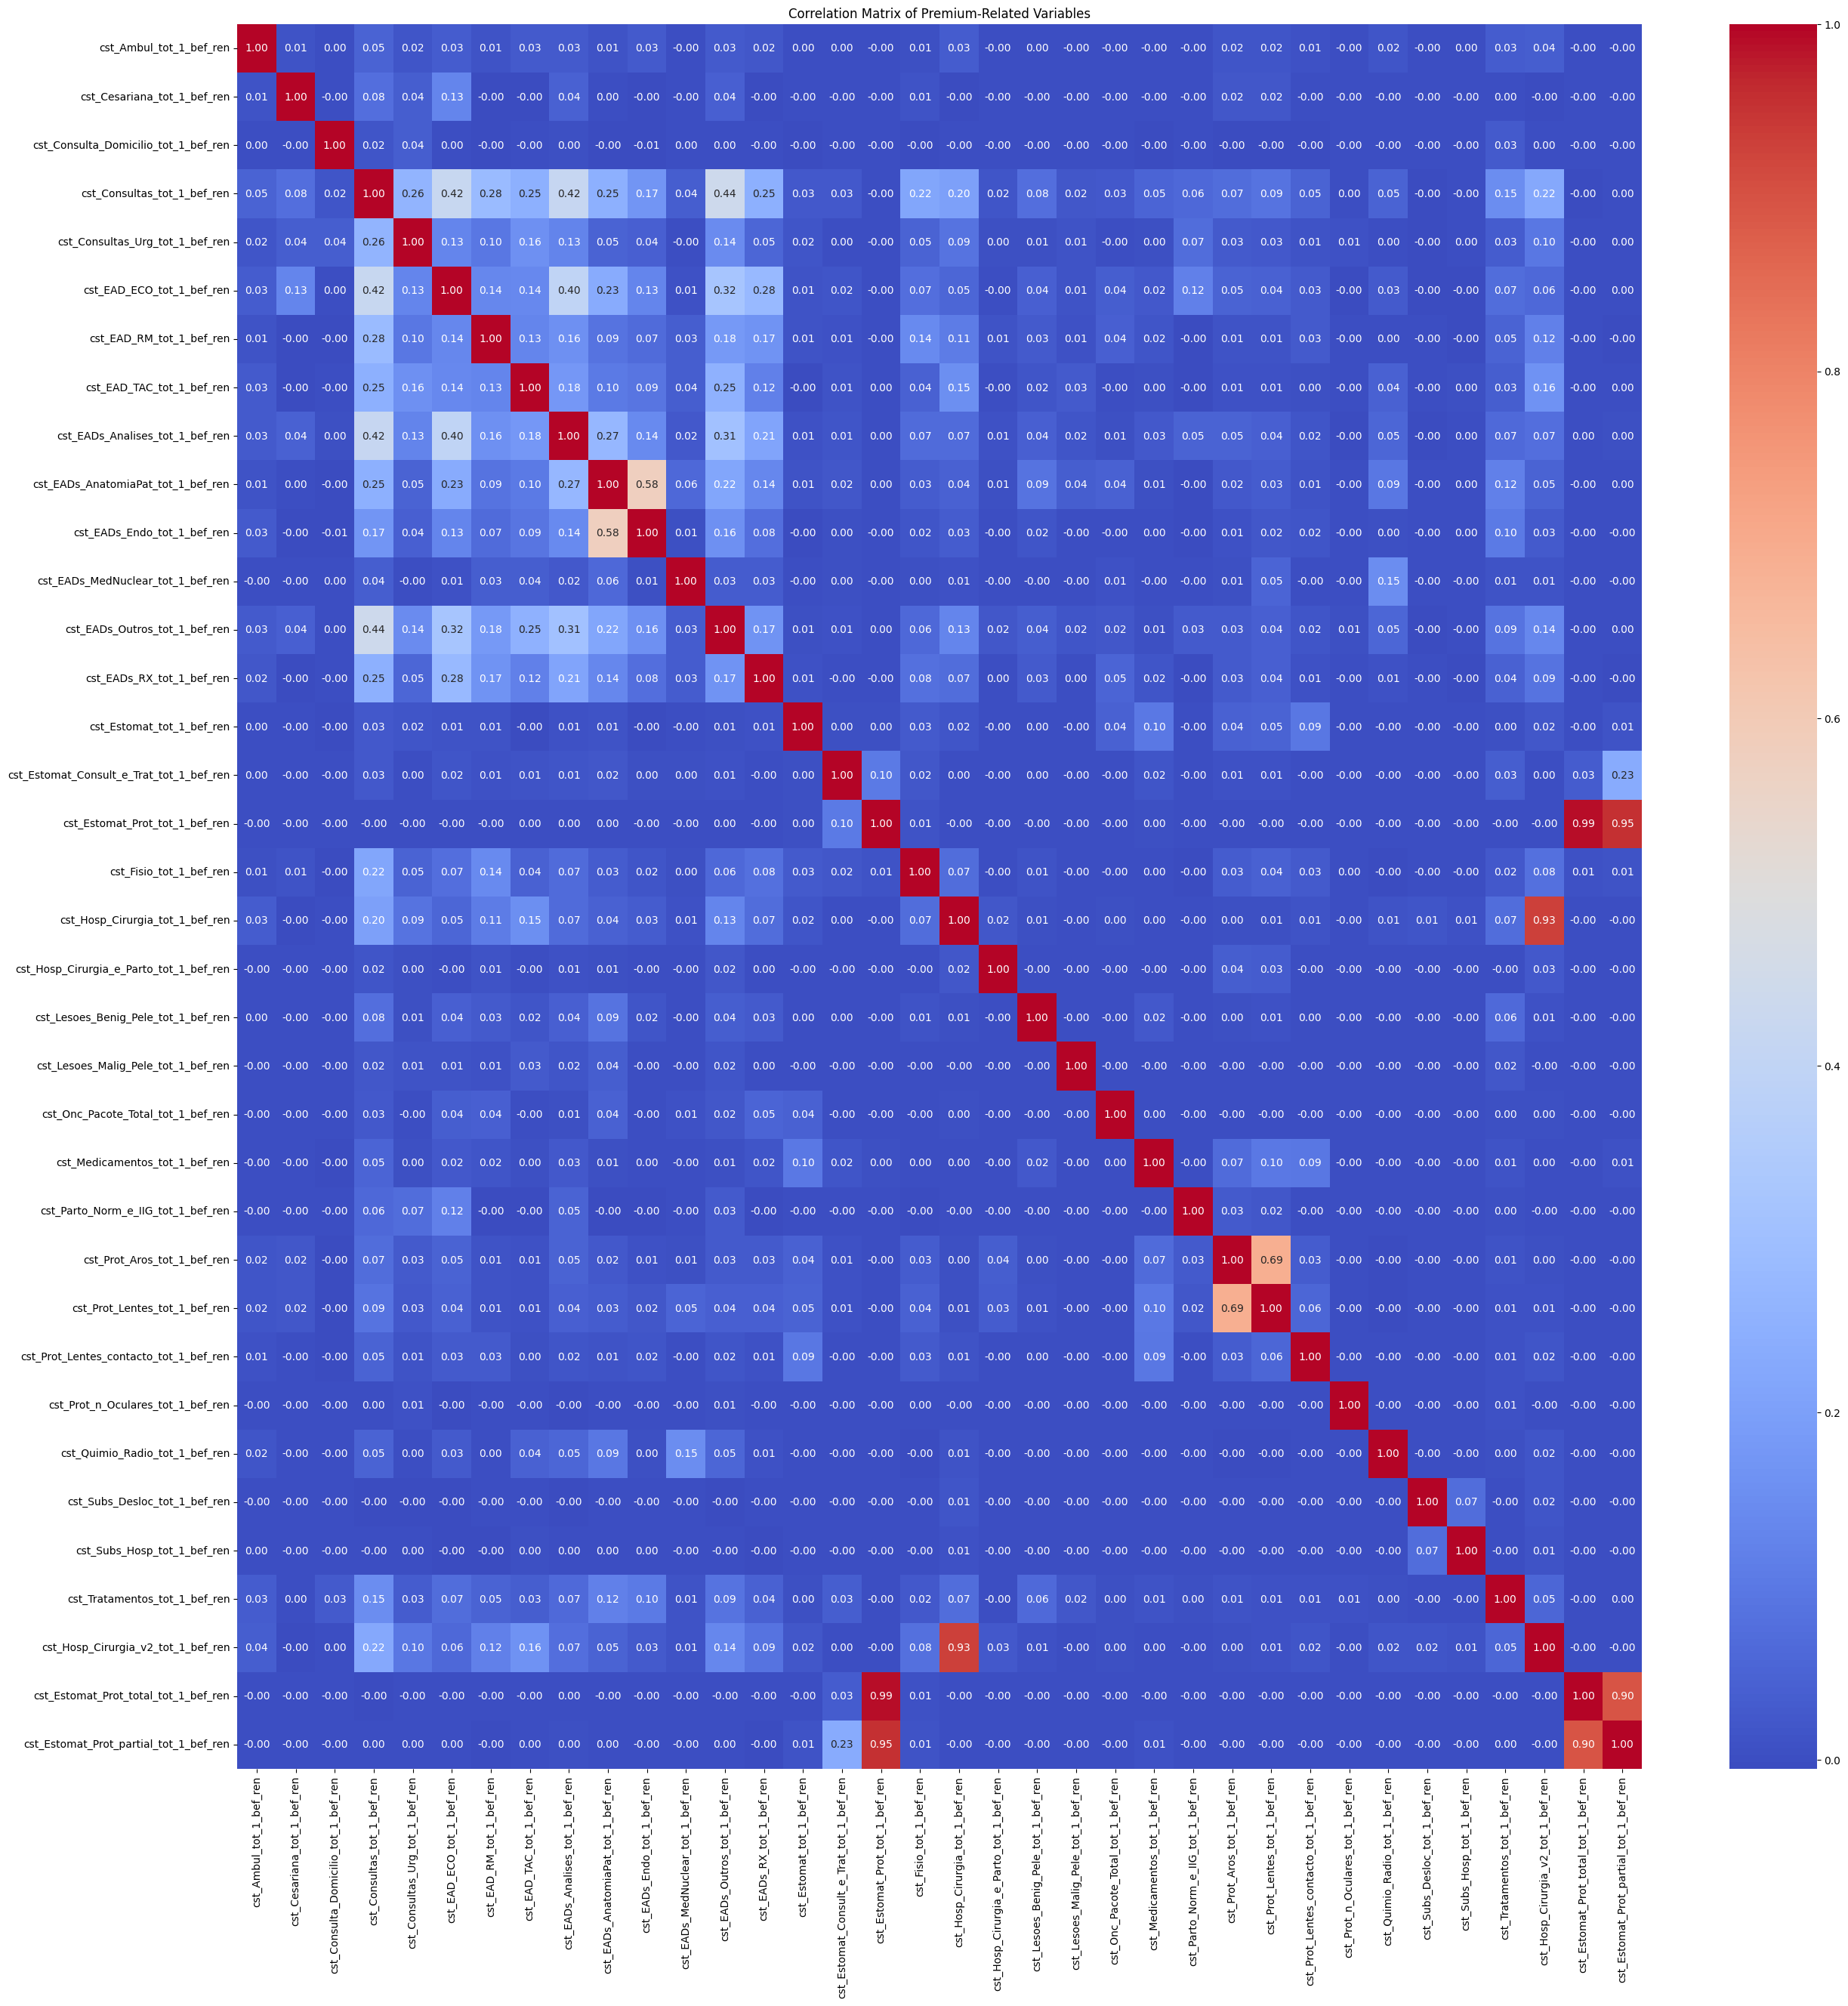

In [26]:
#now lets asses the correlations between the cst 1 year before the renovation 
cst_cols = [col for col in data.columns if col.startswith("cst_")]
cormat =  data[cst_cols].corr()
plt.figure(figsize=(30, 30))
sns.heatmap(cormat, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Premium-Related Variables")
plt.show()



['cst_Estomat_tot_1_bef_ren', 'cst_Estomat_Consult_e_Trat_tot_1_bef_ren', 'cst_Estomat_Prot_tot_1_bef_ren', 'cst_Estomat_Prot_total_tot_1_bef_ren', 'cst_Estomat_Prot_partial_tot_1_bef_ren']
Value counts for cst_Estomat_tot_1_bef_ren:
81


Value counts for cst_Estomat_Consult_e_Trat_tot_1_bef_ren:
20


Value counts for cst_Estomat_Prot_tot_1_bef_ren:
6


Value counts for cst_Estomat_Prot_total_tot_1_bef_ren:
2


Value counts for cst_Estomat_Prot_partial_tot_1_bef_ren:
6




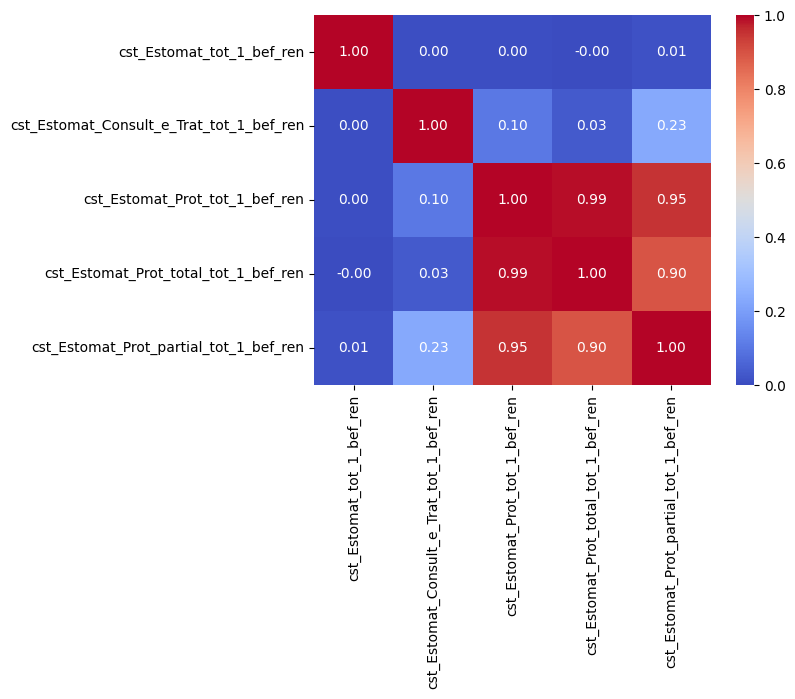

In [27]:
# the only problems im having here are with the dental cases so lets check the cols i have related to estomat and see the individual valuae count for each one then io will see wich omnes i should drop 
estomat_cols = [col for col in data.columns  if col.startswith("cst_Estomat") ]
print(estomat_cols)

for col in estomat_cols:
    print(f"Value counts for {col}:")
    print(data[col].nunique())
    print("\n")


cormat = data[estomat_cols].corr()
plt.figsize=(10, 10)
sns.heatmap(cormat,annot = True, cmap="coolwarm", fmt = ".2f")


# well lets keep just the cols cst_Estomat_tot_1_bef_ren and cst_Estomat_Consult_e_Trat_tot_1_bef_ren
cst_cols_to_drop = [col for col in estomat_cols if col not in ["cst_Estomat_tot_1_bef_ren", "cst_Estomat_Consult_e_Trat_tot_1_bef_ren"]]
data = data.drop(columns=cst_cols_to_drop)


In [28]:
#now lets  check the correlations between th pop indicators 

pop_cols = [col for col in data.columns if col.startswith("POP_")]
cormat =  data[pop_cols].corr()

plt.figure(figsize=(100, 100))
sns.heatmap(cormat, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Premium-Related Variables")

# this matrix is just to big lets just plot the cols wit correlation above 0.6


Text(0.5, 1.0, 'Correlation Matrix of Premium-Related Variables')

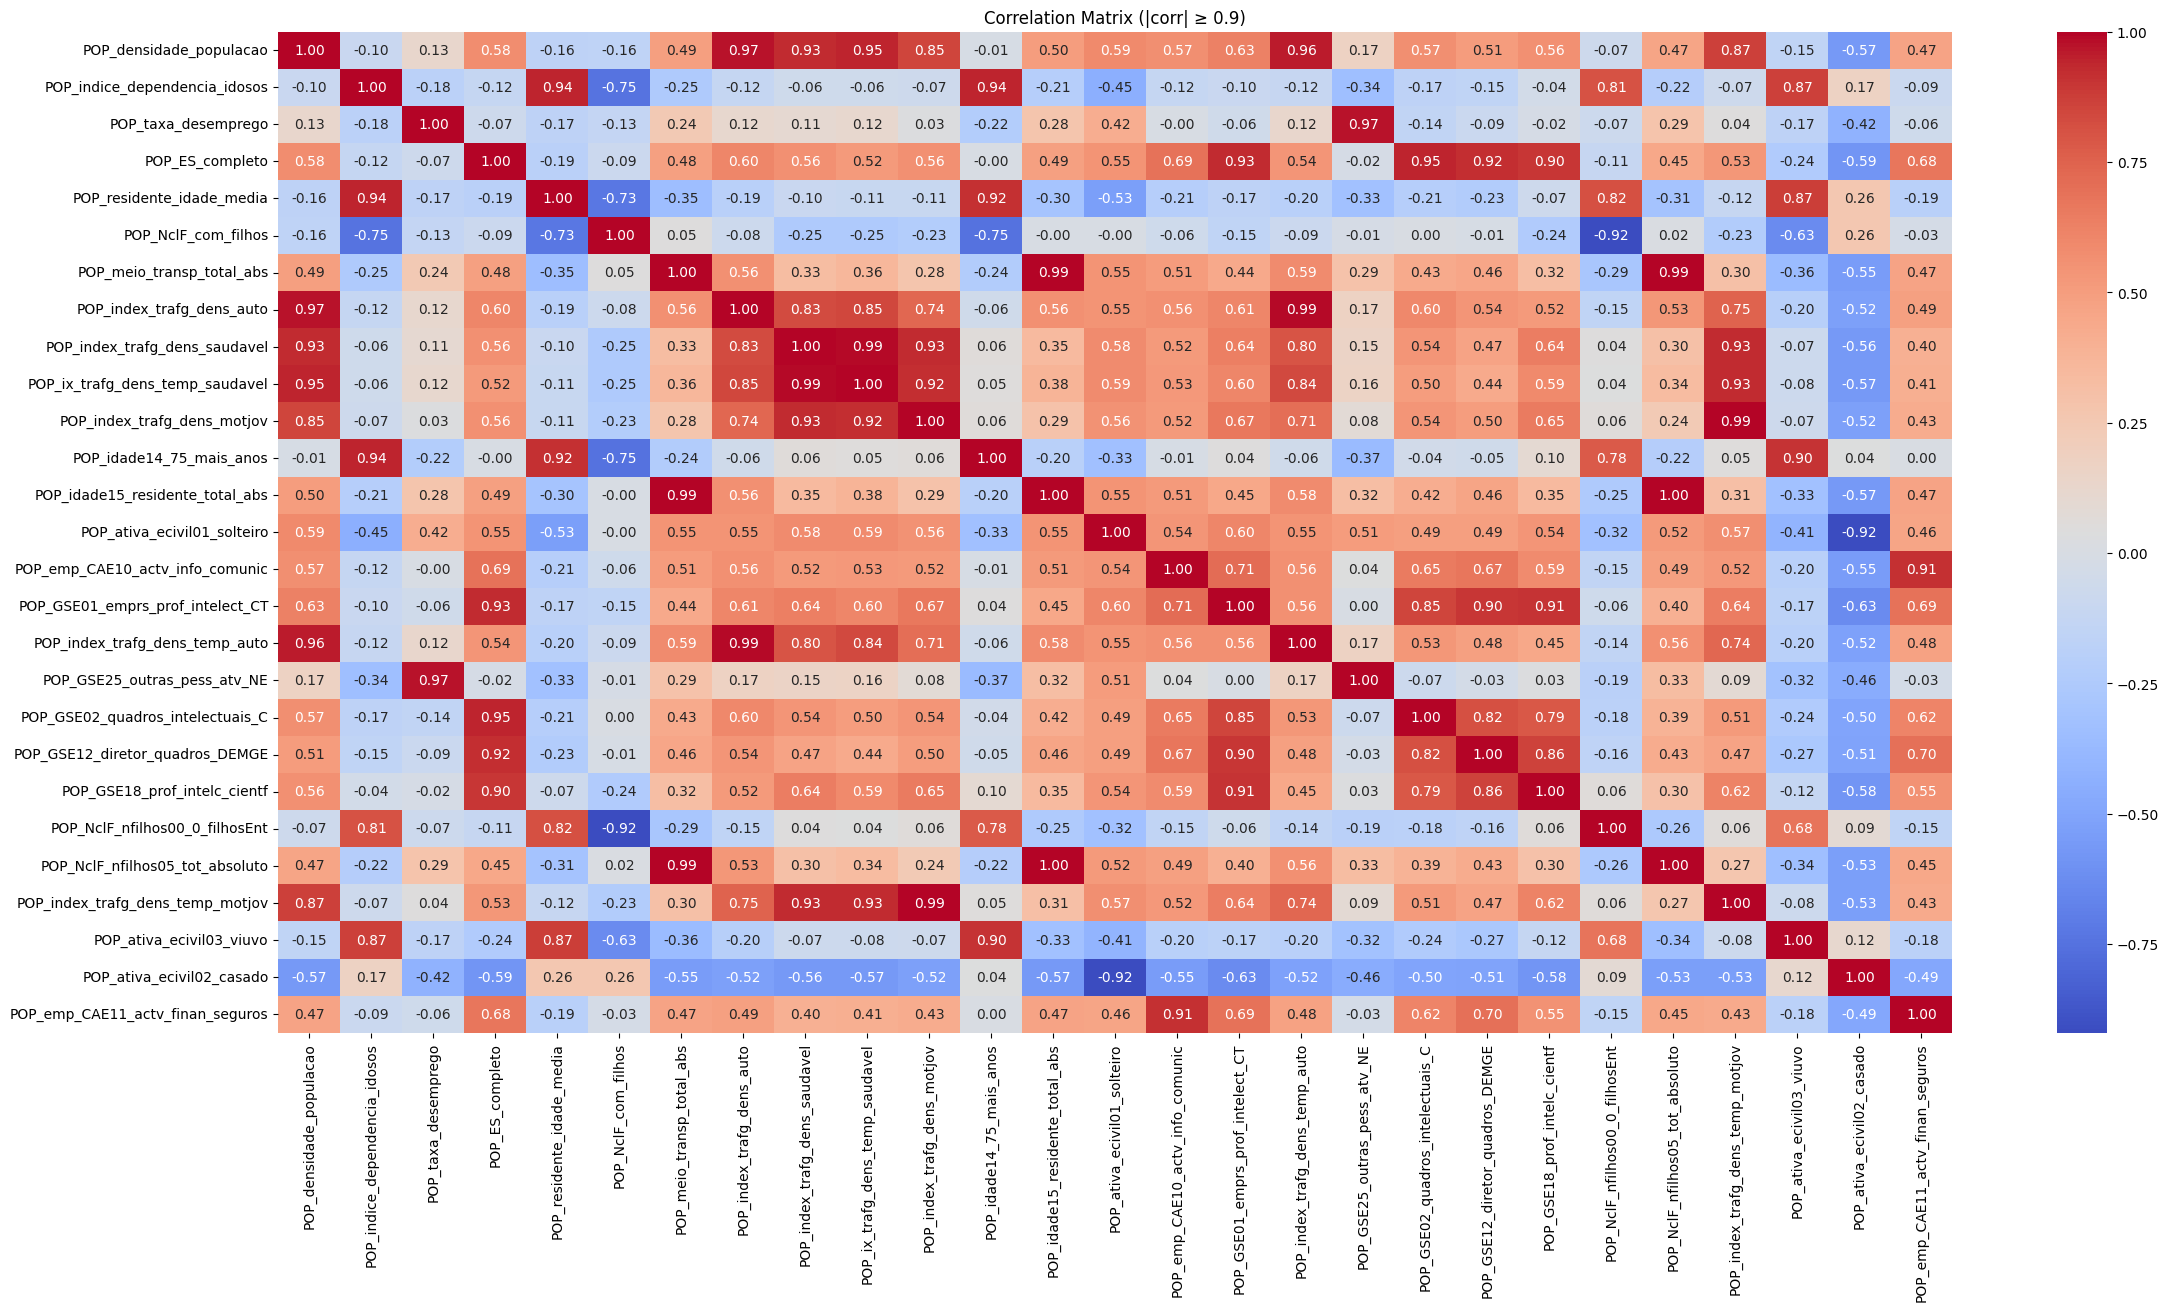

In [29]:

# Get the absolute correlation matrix
cormat_abs = cormat.abs()

# Mask the diagonal and lower triangle
mask = np.triu(np.ones(cormat_abs.shape), k=1).astype(bool)
cormat_upper = cormat_abs.where(mask)

# Find pairs with abs correlation >= 0.9
high_corr_pairs = cormat_upper.stack().reset_index()
high_corr_pairs.columns = ['var1', 'var2', 'correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'] >= 0.9]

# Get unique columns involved in high correlation pairs
high_corr_cols = pd.unique(high_corr_pairs[['var1', 'var2']].values.ravel('K'))

# Plot the correlation matrix for these columns
if len(high_corr_cols) > 1:
    plt.figure(figsize=(max(8, len(high_corr_cols)), max(6, len(high_corr_cols)//2)))
    sns.heatmap(data[high_corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix (|corr| ≥ 0.9)")
    plt.show()
else:
    print("No pairs of variables with absolute correlation ≥ 0.9 found.")

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for all variables in pop_cols
X_vif = data[pop_cols].dropna()
vif_data = []
for i, col in enumerate(X_vif.columns):
    vif = variance_inflation_factor(X_vif.values, i)
    vif_data.append({'variable': col, 'VIF': vif})
vif_df = pd.DataFrame(vif_data)
print(vif_df.sort_values('VIF', ascending=False))

                            variable            VIF
7          POP_residente_idade_media  501473.815768
37         POP_ativa_ecivil02_casado  191384.191305
41    POP_NclF_nfilhos01_1_filhosEnt  186092.413974
40    POP_NclF_nfilhos00_0_filhosEnt  165522.006861
36       POP_ativa_ecivil01_solteiro  148814.932741
..                               ...            ...
9                   POP_AI_dim_media       4.768629
51       POP_emp_CAE05_CTD_agua_SGRD       4.330555
86     POP_GSE19_pequenos_patroes_SP       4.162480
91                POP_GSE24_emprs_SP       3.061603
48  POP_emp_CAE02_industr_extrativas       1.602372

[94 rows x 2 columns]


In [31]:
# This cell defines a reusable function to compute VIF and, if variables `data` and `pop_cols`
# exist in the environment, it computes `VIF_scores` accordingly.

import pandas as pd
import numpy as np

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except Exception as e:
    raise RuntimeError(
        "statsmodels is required for VIF computation. Please ensure it is available in the environment."
    )


def compute_vif(df: pd.DataFrame, columns):
    """Compute VIF for the given columns in df.

    - Keeps only numeric columns among `columns`.
    - Drops rows with NA in the selected columns (VIF needs complete cases).
    - Adds a constant column for stability but **does not** report VIF for the constant.
    - Returns a pandas Series sorted descending by VIF.
    """
    # Ensure columns exist
    cols = [c for c in columns if c in df.columns]
    if len(cols) == 0:
        raise ValueError("None of the specified columns are in the DataFrame.")

    # Keep numeric only (VIF requires numeric predictors)
    numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) == 0:
        raise ValueError("None of the specified columns are numeric. Encode categoricals first.")

    X = df[numeric_cols].copy()

    # Drop rows with missing values for VIF computation
    X_clean = X.dropna(axis=0)

    # If any column has zero variance, VIF is undefined; drop those and warn
    variances = X_clean.var(axis=0)
    zero_var_cols = variances[variances == 0].index.tolist()
    if zero_var_cols:
        X_clean = X_clean.drop(columns=zero_var_cols)

    # Add intercept for stability
    X_with_const = pd.concat([pd.Series(1.0, index=X_clean.index, name="const"), X_clean], axis=1)

    # Compute VIF for each real feature (skip const at index 0)
    vif_values = []
    for i, col in enumerate(X_with_const.columns):
        if col == "const":
            continue
        vif_val = variance_inflation_factor(X_with_const.values, i)
        vif_values.append((col, float(vif_val)))

    vif_series = pd.Series(dict(vif_values), name="VIF").sort_values(ascending=False)
    return vif_series


# If `data` and `pop_cols` are already in the environment, compute VIF_scores.
VIF_scores = None
if 'data' in globals() and 'pop_cols' in globals():
    try:
        VIF_scores = compute_vif(data, pop_cols)
    except Exception as e:
        VIF_scores = e
else:
    # No-op when variables are not present; user can call compute_vif(data, pop_cols) after defining them.
    VIF_scores = "Variables `data` and/or `pop_cols` not found in the environment. Define them and re-run compute_vif(data, pop_cols)."

# For visibility in this environment, print a brief status (won't be too verbose)
print("VIF_scores prepared:", type(VIF_scores))

VIF_scores prepared: <class 'pandas.Series'>


In [32]:
# lets just keep cols where VIF is beloww 10 and drop the rest 
cols_withVIF_below_10 = VIF_scores[VIF_scores < 10].index.tolist()

In [33]:
VIF_scores[VIF_scores.index.isin(cols_withVIF_below_10)]

POP_durac_media_mov_pendular        9.890541
POP_emp_CAE12_actv_imabiliarias     9.344343
POP_GSE17_prof_tecn_interm_I        9.279719
POP_GSE15_prestad_serv_CI           9.277695
POP_GSE13_emprs_ind_com_serv        9.048924
POP_emp_CAE24_Total_absoluto        9.018301
POP_indice_envelhecimento           8.914098
POP_emp_CAE03_indust_transformad    8.462452
POP_GSE21_pequenos_patroes_I        8.226899
POP_emp_CAE09_aloj_resta_simil      7.527615
POP_GSE20_pequenos_patroes_CS       7.080579
POP_emp_CAE18_actv_artist_EDR       5.823173
POP_emp_CAE21_act_org_int_OIET      5.789309
POP_emp_CAE16_educacao              5.457325
POP_emp_CAE08_transpo_armazenag     5.451311
POP_GSE03_forcas_armadas            5.320974
POP_emp_CAE01_Agric_PA_C_Fl_Pesc    5.272735
POP_emp_CAE15_adm_publ_def_SSO      5.173062
POP_GSE10_quadros_admin_interm      4.878102
POP_emp_CAE19_outr_act_servc        4.816689
POP_emp_CAE14_act_adm_serv_apoio    4.442247
POP_GSE22_pequenos_patroes_PTI      4.026143
POP_emp_CA

In [34]:
cst_cols_to_drop= [col for col in pop_cols if col not in cols_withVIF_below_10]
data = data.drop(columns=cst_cols_to_drop)

In [35]:
# lets save this dataframe into a parquet file 
data.to_parquet("data_before_model3_v2.parquet")